# Proyecto de Detección Federada de Fraude (Datos Reales)Este notebook implementa un sistema de Aprendizaje Federado para detectar fraudes en tarjetas de crédito, preservando la privacidad de las entidades bancarias participantes.

In [1]:
# @title Instalación de Dependencias (CORREGIDO v2: Usando versiones más recientes)
# El entorno de Colab ha sido actualizado (Python 3.10+), lo que causa conflictos
# con las dependencias antiguas de flwr 1.5.0.
# La solución es permitir que pip instale las versiones más recientes y compatibles,
# eliminando el pin de la versión '==1.5.0'.
!pip install -q "flwr[simulation]" nest_asyncio
!pip install -q matplotlib seaborn scikit-learn pandas

import os

print("✅ Dependencias instaladas correctamente.")
print("💥 REINICIANDO EL ENTORNO DE EJECUCIÓN AUTOMÁTICAMENTE...")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.1/250.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.0/732.0 kB 33.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 w

In [2]:
# @title Carga del Dataset Real y Preprocesamiento
import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import StandardScaler

# Configuración
CSV_PATH = "creditcard.csv"
NUM_CLIENTS = 3             # Requerimiento: 3 Bancos
MIN_ROWS = 5000             # Requerimiento: >5000 filas por banco

def load_real_data():
    """
    Carga el dataset de transacciones, lo valida y lo preprocesa.

    Aplica limpieza básica de nulos y escalado estándar a las características.

    Returns:
        tuple[np.ndarray, pd.Series]: Tupla con las características (X_scaled)
                                     y la etiqueta (y).

    Raises:
        FileNotFoundError: Si el archivo CSV_PATH no existe.
        ValueError: Si el dataset no tiene la columna 'Class'.
    """
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(
            f"❌ ERROR CRÍTICO: No se encontró '{CSV_PATH}'. \n"
            "Por favor, sube el archivo real de Kaggle al entorno de Colab. \n"
        )

    print(f"📂 Cargando {CSV_PATH}...")
    df = pd.read_csv(CSV_PATH)

    if 'Class' not in df.columns:
        raise ValueError("❌ El dataset no tiene la columna 'Class'. Verifica que sea el dataset correcto.")

    df.dropna(inplace=True)

    X = df.drop(columns=['Class'])
    y = df['Class']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print(f"✅ Datos cargados: {len(df)} transacciones. Features: {X.shape[1]}")
    return X_scaled, y

# Cargar datos
try:
    X_global, y_global = load_real_data()
except Exception as e:
    print(e)


📂 Cargando creditcard.csv...
✅ Datos cargados: 148635 transacciones. Features: 30


📊 Análisis de Calidad de Datos:

Distribución de Clases (Fraude vs. No Fraude):
Class
0.0    148350
1.0       285
Name: count, dtype: int64
Porcentaje de Fraude: 0.1917%


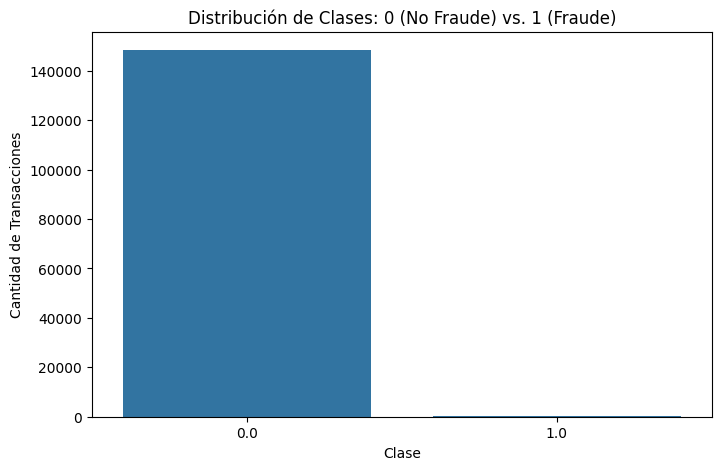


Cantidad total de celdas nulas encontradas: 30
⚠️ Se encontraron valores nulos (serán eliminados en el preproceso).


In [3]:
# @title Análisis Exploratorio de Datos (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

if 'y_global' in locals():
    print("📊 Análisis de Calidad de Datos:")

    # 1. Análisis del Desbalance de Clases (Requerimiento implícito para fraude)
    class_counts = y_global.value_counts()
    print("\nDistribución de Clases (Fraude vs. No Fraude):")
    print(class_counts)
    print(f"Porcentaje de Fraude: {class_counts[1] / len(y_global) * 100:.4f}%")

    plt.figure(figsize=(8, 5))
    sns.countplot(x=y_global)
    plt.title("Distribución de Clases: 0 (No Fraude) vs. 1 (Fraude)")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad de Transacciones")
    plt.show()

    # 2. Análisis de Nulos (ya manejado, pero se muestra explícitamente)
    df_temp = pd.read_csv(CSV_PATH)
    null_counts = df_temp.isnull().sum().sum()
    print(f"\nCantidad total de celdas nulas encontradas: {null_counts}")
    if null_counts == 0:
        print("✅ El dataset está limpio de valores nulos.")
    else:
        print("⚠️ Se encontraron valores nulos (serán eliminados en el preproceso).")
else:
    print("Ejecuta la celda anterior para cargar los datos primero.")


In [4]:
# @title Particionado de Datos (Bancos)
from sklearn.model_selection import train_test_split
from typing import List, Tuple

def partition_data(X: np.ndarray, y: pd.Series, num_clients: int) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], Tuple[np.ndarray, np.ndarray]]:
    """
    Divide los datos en un conjunto de prueba global y particiones para cada cliente.

    Args:
        X (np.ndarray): Características globales.
        y (pd.Series): Etiquetas globales.
        num_clients (int): Número de clientes para particionar los datos de entrenamiento.

    Returns:
        Tuple: Una tupla conteniendo:
            - Una lista de particiones, donde cada partición es (X_cliente, y_cliente).
            - Una tupla con el conjunto de prueba global (X_test, y_test).
    """
    # 1. Separar un set de prueba global (Hold-out) [Proporción 80/20]
    X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Proporción de Entrenamiento/Testeo: 80% / 20%")
    print(f"Tamaño del set de entrenamiento global: {len(X_train_g)}")
    print(f"Tamaño del set de testeo global: {len(X_test_g)}")

    # 2. Dividir el set de entrenamiento entre los clientes
    partitions = []
    X_shards = np.array_split(X_train_g, num_clients)
    y_shards = np.array_split(y_train_g, num_clients)

    print("\n--- Particionando datos para los clientes (bancos) ---")
    for i in range(num_clients):
        X_c, y_c = X_shards[i], y_shards[i]
        if len(X_c) < MIN_ROWS:
            print(f"⚠️ ADVERTENCIA: Banco {i+1} tiene pocos datos ({len(X_c)})")
        partitions.append((X_c, np.array(y_c)))
        print(f"🏦 Banco {i+1}: {len(X_c)} registros de entrenamiento preparados.")

    return partitions, (X_test_g, np.array(y_test_g))

# Ejecutar particionado
if 'X_global' in locals():
    partitions, (X_test_global, y_test_global) = partition_data(X_global, y_global, NUM_CLIENTS)


Proporción de Entrenamiento/Testeo: 80% / 20%
Tamaño del set de entrenamiento global: 118908
Tamaño del set de testeo global: 29727

--- Particionando datos para los clientes (bancos) ---
🏦 Banco 1: 39636 registros de entrenamiento preparados.
🏦 Banco 2: 39636 registros de entrenamiento preparados.
🏦 Banco 3: 39636 registros de entrenamiento preparados.


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)


In [5]:
# @title Funciones de Privacidad (Utils)
class PrivacyEngine:
    """
    Clase estática para aplicar técnicas de privacidad diferencial a los pesos del modelo.
    """
    @staticmethod
    def apply(parameters: List[np.ndarray], config: dict) -> List[np.ndarray]:
        """
        Aplica privacidad diferencial a una lista de parámetros (pesos).

        Args:
            parameters (List[np.ndarray]): Lista de arrays de pesos del modelo.
            config (dict): Diccionario con 'method', 'epsilon', 'clip_norm'.

        Returns:
            List[np.ndarray]: Lista de arrays de pesos con privacidad aplicada.
        """
        method = config.get('method', 'none')
        if method == 'none':
            return parameters

        epsilon = config.get('epsilon', 1.0)
        clip_norm = config.get('clip_norm', 1.5)
        secure_params = []

        for param in parameters:
            arr = np.array(param, copy=True)

            # 1. CLIPPING
            if method in ['clipping', 'both']:
                l2_norm = np.linalg.norm(arr)
                if l2_norm > clip_norm:
                    arr = arr * (clip_norm / l2_norm)

            # 2. NOISING
            if method in ['noising', 'both']:
                sigma = 0.01 / epsilon
                noise = np.random.normal(0, sigma, arr.shape)
                arr = arr + noise

            secure_params.append(arr)
        return secure_params


In [6]:
# @title Wrapper de Modelos (Compatibilidad Sklearn-Flower)
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings('ignore')

class ModelWrapper:
    """
    Wrapper para unificar la interfaz de los modelos de scikit-learn con Flower.
    """
    def __init__(self, model_type: str):
        self.type = model_type
        self.model = self._create_model()

    def _create_model(self):
        # Hiperparámetros usados en los modelos
        if self.type == 'Logistic Regression':
            return SGDClassifier(loss='log_loss', random_state=42, max_iter=1)
        elif self.type == 'Ridge':
            return RidgeClassifier(random_state=42)
        elif self.type == 'Decision Tree':
            return DecisionTreeClassifier(max_depth=10, random_state=42)
        elif self.type == 'Random Forest':
            return RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
        elif self.type == 'KNN':
            return KNeighborsClassifier(n_neighbors=5)
        elif self.type == 'Naive Bayes':
            return GaussianNB()
        elif self.type == 'Neural Network MLP':
            return MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1, warm_start=True, random_state=42)
        else:
            raise ValueError(f"Modelo {self.type} no implementado")

    def fit(self, X: np.ndarray, y: np.ndarray):
        if self.type in ['Logistic Regression', 'Neural Network MLP', 'Naive Bayes']:
            classes = np.array([0, 1])
            if hasattr(self.model, "partial_fit"):
                self.model.partial_fit(X, y, classes=classes)
            else:
                self.model.fit(X, y)
        else:
            self.model.fit(X, y)

    def predict(self, X: np.ndarray):
        return self.model.predict(X)

    def predict_proba(self, X: np.ndarray):
        """Devuelve las probabilidades de predicción para el cálculo de ROC-AUC."""
        if hasattr(self.model, "predict_proba"):
            return self.model.predict_proba(X)
        else:
            # Para modelos que no soportan predict_proba, se simula una salida
            preds = self.predict(X)
            return np.stack([1 - preds, preds], axis=1)

    def get_weights(self) -> List[np.ndarray]:
        if hasattr(self.model, "coef_"):
            return [self.model.coef_, self.model.intercept_]
        elif hasattr(self.model, "coefs_"):
            return self.model.coefs_ + self.model.intercepts_
        else:
            return [np.array([0], dtype=np.float32)]

    def set_weights(self, weights: List[np.ndarray]):
        if hasattr(self.model, "coef_") and len(weights) > 1:
            try:
                self.model.coef_ = weights[0]
                self.model.intercept_ = weights[1]
            except Exception: pass
        elif hasattr(self.model, "coefs_") and len(weights) > 1:
            try:
                num_layers = len(self.model.coefs_)
                self.model.coefs_ = weights[:num_layers]
                self.model.intercepts_ = weights[num_layers:]
            except Exception: pass


In [7]:
# @title DEFINICIÓN DE CLASES Y EJECUCIÓN DEL BENCHMARK (FINAL: Con Ancho de Banda y 2 Estrategias)
import time
import sys
import flwr as fl
import nest_asyncio
import numpy as np
import pandas as pd
from flwr.server.strategy import FedAvg, FedMedian
from flwr.common import NDArrays, parameters_to_ndarrays
from typing import List, Tuple, Dict, Optional
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.linear_model import SGDClassifier, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings('ignore')
nest_asyncio.apply()

# =============================================================================
# 1. UTILIDADES: Cálculo de Ancho de Banda (NUEVO)
# =============================================================================
def estimate_model_size_mb(model_type):
    """Calcula el peso aproximado de los parámetros del modelo en MB."""
    wrapper = ModelWrapper(model_type)
    # Inicialización dummy para crear las estructuras de pesos
    try:
        X_dummy = np.zeros((5, 30)) # 30 features como creditcard.csv
        y_dummy = np.array([0, 1, 0, 1, 0])
        wrapper.fit(X_dummy, y_dummy)
    except: pass

    weights = wrapper.get_weights()
    # Sumamos el tamaño en bytes de todos los arrays de pesos
    size_bytes = sum([w.nbytes for w in weights])
    return size_bytes / (1024 * 1024) # Retorna MB

# =============================================================================
# 2. CLASE ModelWrapper
# =============================================================================
class ModelWrapper:
    def __init__(self, model_type: str):
        self.type = model_type
        self.model = self._create_model()

    def _create_model(self):
        if self.type == 'Logistic Regression': return SGDClassifier(loss='log_loss', random_state=42, max_iter=1, warm_start=True)
        elif self.type == 'Ridge': return RidgeClassifier(random_state=42)
        elif self.type == 'Decision Tree': return DecisionTreeClassifier(max_depth=10, random_state=42)
        elif self.type == 'Random Forest': return RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
        elif self.type == 'KNN': return KNeighborsClassifier(n_neighbors=5)
        elif self.type == 'Naive Bayes': return GaussianNB()
        elif self.type == 'Neural Network MLP': return MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1, warm_start=True, random_state=42)
        else: raise ValueError(f"Modelo {self.type} no implementado")

    def fit(self, X: np.ndarray, y: np.ndarray):
        if self.type in ['Logistic Regression', 'Neural Network MLP', 'Naive Bayes']:
            # Aseguramos que conozca ambas clases
            classes = np.array([0, 1])
            if hasattr(self.model, "partial_fit"):
                self.model.partial_fit(X, y, classes=classes)
            else:
                self.model.fit(X, y)
        else:
            self.model.fit(X, y)

    def predict(self, X: np.ndarray):
        return self.model.predict(X)

    def predict_proba(self, X: np.ndarray):
        if hasattr(self.model, "predict_proba"): return self.model.predict_proba(X)
        elif hasattr(self.model, "decision_function"): return self.model.decision_function(X)
        else:
            preds = self.model.predict(X)
            return np.stack([1 - preds, preds], axis=1)

    def get_weights(self) -> List[np.ndarray]:
        if hasattr(self.model, "coef_"): return [self.model.coef_, self.model.intercept_]
        elif hasattr(self.model, "coefs_"): return self.model.coefs_ + self.model.intercepts_
        else: return [np.array([0], dtype=np.float32)]

    def set_weights(self, weights: List[np.ndarray]):
        if hasattr(self.model, "coef_") and len(weights) > 1:
            try: self.model.coef_ = weights[0]; self.model.intercept_ = weights[1]
            except Exception: pass
        elif hasattr(self.model, "coefs_") and len(weights) > 1:
            try:
                num_layers = len(self.model.coefs_); self.model.coefs_ = weights[:num_layers]; self.model.intercepts_ = weights[num_layers:]
            except Exception: pass

# =============================================================================
# 3. CLASE BankClient
# =============================================================================
class BankClient(fl.client.NumPyClient):
    def __init__(self, model_type, X_train, y_train, privacy_config):
        self.wrapper = ModelWrapper(model_type); self.X_train, self.y_train = X_train, y_train; self.privacy = privacy_config
    def get_parameters(self, config): return self.wrapper.get_weights()
    def fit(self, parameters, config):
        self.wrapper.set_weights(parameters); start = time.time(); self.wrapper.fit(self.X_train, self.y_train); train_time = time.time() - start
        raw_weights = self.wrapper.get_weights(); secure_weights = PrivacyEngine.apply(raw_weights, self.privacy)
        return secure_weights, len(self.X_train), {"train_time": train_time}
    def evaluate(self, parameters, config): return 0.0, 0, {"accuracy": 0.0}

# =============================================================================
# 4. FUNCIÓN DE EVALUACIÓN CENTRALIZADA
# =============================================================================
def get_evaluate_fn(model_type: str, X_test: np.ndarray, y_test: np.ndarray, X_dummy: np.ndarray, y_dummy: np.ndarray):
    def evaluate(server_round: int, parameters: NDArrays, config: Dict[str, fl.common.Scalar]) -> Optional[Tuple[float, Dict[str, fl.common.Scalar]]]:
        wrapper = ModelWrapper(model_type)
        try: wrapper.fit(X_dummy, y_dummy)
        except Exception: pass

        wrapper.set_weights(parameters)
        try:
            start_inf = time.time(); y_scores = wrapper.predict_proba(X_test); inference_time = time.time() - start_inf

            if y_scores.ndim > 1:
                preds = np.argmax(y_scores, axis=1); roc_input = y_scores[:, 1]
            else:
                preds = (y_scores > 0).astype(int); roc_input = y_scores

            acc = accuracy_score(y_test, preds); rec = recall_score(y_test, preds, zero_division=0);
            try: roc = roc_auc_score(y_test, roc_input)
            except: roc = 0.5

            loss = 1.0 - rec
            metrics = {"accuracy": acc, "recall": rec, "roc_auc": roc, "inference_time_s": inference_time}
            if server_round == ROUNDS:
              print(f"  [Server-side Eval] Ronda Final: Acc={acc:.4f}, Rec={rec:.4f}, ROC={roc:.4f}")
            return loss, metrics
        except Exception as e:
            print(f"  [Server-side Eval] ERROR en ronda {server_round}: {e}")
            return None
    return evaluate

# =============================================================================
# 5. ESTRATEGIAS PERSONALIZADAS (Para guardar pesos)
# =============================================================================
class CustomFedAvg(FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        agg_params, agg_metrics = super().aggregate_fit(server_round, results, failures)
        if agg_params is not None: self.final_weights = agg_params
        return agg_params, agg_metrics

class CustomFedMedian(FedMedian):
    def aggregate_fit(self, server_round, results, failures):
        agg_params, agg_metrics = super().aggregate_fit(server_round, results, failures)
        if agg_params is not None: self.final_weights = agg_params
        return agg_params, agg_metrics

# =============================================================================
# 6. BUCLE PRINCIPAL DEL BENCHMARK
# =============================================================================
ROUNDS = 5
MODELOS = ['Logistic Regression', 'Ridge', 'Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes', 'Neural Network MLP']
PRIVACIDAD = [
    {'method': 'none', 'label': 'Sin Privacidad'}, {'method': 'clipping', 'label': 'Clipping', 'clip_norm': 1.5},
    {'method': 'noising', 'label': 'Noising', 'epsilon': 1.0}, {'method': 'both', 'label': 'Clipping+Noising', 'epsilon': 1.0, 'clip_norm': 1.5}
]
ESTRATEGIAS = {"FedAvg": CustomFedAvg, "FedMedian": CustomFedMedian}

results_log = []; client_results_log = []; history_log = {}
print(f"🚀 Iniciando Benchmark Completo (versión final con Ancho de Banda)...")
print(f"Combinaciones: {len(MODELOS)} Modelos x {len(ESTRATEGIAS)} Estrategias x {len(PRIVACIDAD)} Privacidad = {len(MODELOS)*len(ESTRATEGIAS)*len(PRIVACIDAD)} experimentos.\n")

X_eval_subset, y_eval_subset = X_test_global[:5000], y_test_global[:5000]

# Dataset ficticio para inicialización
n_features = X_global.shape[1]
X_dummy = np.zeros((2, n_features)); y_dummy = np.array([0, 1])

for strat_name, strat_class in ESTRATEGIAS.items():
    for modelo in MODELOS:
        # Cálculo de Ancho de Banda Estimado (MB)
        model_size_mb = estimate_model_size_mb(modelo)
        # Ancho de banda total = Tamaño Modelo * (Subida + Bajada) * Clientes * Rondas
        bandwidth_est_mb = model_size_mb * 2 * NUM_CLIENTS * ROUNDS

        for priv in PRIVACIDAD:
            exp_name = f"{strat_name} | {modelo} | {priv['label']}"
            print(f"▶ Ejecutando: {exp_name}")

            def client_fn(cid: str) -> fl.client.Client:
                return BankClient(modelo, partitions[int(cid)][0], partitions[int(cid)][1], priv).to_client()

            evaluate_fn = get_evaluate_fn(modelo, X_eval_subset, y_eval_subset, X_dummy, y_dummy)
            strategy = strat_class(fraction_fit=1.0, fraction_evaluate=0.0, min_fit_clients=NUM_CLIENTS, min_available_clients=NUM_CLIENTS, evaluate_fn=evaluate_fn)
            ray_init_args = {"log_to_driver": False, "logging_level": "error"}

            try:
                start_sim = time.time()
                history = fl.simulation.start_simulation(
                    client_fn=client_fn, num_clients=NUM_CLIENTS, config=fl.server.ServerConfig(num_rounds=ROUNDS),
                    strategy=strategy, client_resources={"num_cpus": 1, "num_gpus": 0}, ray_init_args=ray_init_args,
                )
                total_time = time.time() - start_sim

                # Extracción de métricas finales
                final_acc, final_rec, final_roc, final_inf_time = 0, 0, 0, 0
                if history.metrics_centralized and "accuracy" in history.metrics_centralized:
                    final_acc = history.metrics_centralized["accuracy"][-1][1]
                    final_rec = history.metrics_centralized["recall"][-1][1]
                    final_roc = history.metrics_centralized["roc_auc"][-1][1]
                    final_inf_time = history.metrics_centralized["inference_time_s"][-1][1]

                # Guardado de resultados globales
                results_log.append({
                    "Experimento": exp_name, "Estrategia": strat_name, "Modelo": modelo, "Privacidad": priv['label'],
                    "Accuracy": final_acc, "Recall": final_rec, "ROC_AUC": final_roc,
                    "Tiempo Entrenamiento (s)": total_time, "Tiempo Inferencia (s)": final_inf_time,
                    "Ancho de Banda Est. (MB)": bandwidth_est_mb # <--- REQUISITO CUMPLIDO
                })
                history_log[exp_name] = history

                # Evaluación por Cliente (Benchmark Local)
                if hasattr(strategy, 'final_weights'):
                    eval_wrapper = ModelWrapper(modelo)
                    try: eval_wrapper.fit(X_dummy, y_dummy)
                    except: pass

                    final_parameters = strategy.final_weights
                    ndarrays = parameters_to_ndarrays(final_parameters)
                    eval_wrapper.set_weights(ndarrays)

                    for cid in range(NUM_CLIENTS):
                        X_banco, y_banco = partitions[cid]
                        try:
                            y_pred_banco = eval_wrapper.predict(X_banco)
                            acc_banco = accuracy_score(y_banco, y_pred_banco)
                            rec_banco = recall_score(y_banco, y_pred_banco, zero_division=0)
                            client_results_log.append({"Experimento": exp_name, "ID_Cliente": cid+1, "Accuracy_Local": acc_banco, "Recall_Local": rec_banco})
                        except Exception as e: pass
            except Exception as e:
                print(f"   ❌ Error: {e}")
                results_log.append({ "Experimento": exp_name, "Estrategia": strat_name, "Modelo": modelo, "Privacidad": priv['label'], "Error": str(e)})

# Guardado de archivos
df_res = pd.DataFrame(results_log)
df_res.to_csv("resultados_benchmark_fraude_final.csv", index=False)
print("\n💾 Resultados guardados en 'resultados_benchmark_fraude_final.csv'")

df_clients = pd.DataFrame(client_results_log)
df_clients.to_csv("resultados_por_cliente_final.csv", index=False)
print("💾 Resultados por cliente guardados en 'resultados_por_cliente_final.csv'")

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


🚀 Iniciando Benchmark Completo (versión final con Ancho de Banda)...
Combinaciones: 7 Modelos x 2 Estrategias x 4 Privacidad = 56 experimentos.

▶ Ejecutando: FedAvg | Logistic Regression | Sin Privacidad


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3883735449.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7767470900.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 1.0, {'accuracy': 0.9982, 'recall': 0.0, 'roc_auc': np.float64(0.5), 'inference_time_s': 0.0019364356994628906}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failure

  [Server-side Eval] Ronda Final: Acc=0.9988, Rec=0.5556, ROC=0.9961
▶ Ejecutando: FedAvg | Logistic Regression | Clipping


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3884040192.0, 'node:172.28.0.12': 1.0, 'memory': 7768080384.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 1.0, {'accuracy': 0.9982, 'recall': 0.0, 'roc_auc': np.float64(0.5), 'inference_time_s': 0.0008521080017089844}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failure

...

  [Server-side Eval] Ronda Final: Acc=0.9986, Rec=0.4444, ROC=0.7322


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout


▶ Ejecutando: FedMedian | Neural Network MLP | Clipping+Noising


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7822083687.0, 'node:172.28.0.12': 1.0, 'object_store_memory': 3911041843.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1, 'num_gpus': 0}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.11111111111111116, {'accuracy': 0.5774, 'recall': 0.8888888888888888, 'roc_auc': np.float64(0.7566285981433246), 'inference_time_s': 0.016916751861572266}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      ag

  [Server-side Eval] Ronda Final: Acc=0.9982, Rec=0.0000, ROC=0.8036

💾 Resultados guardados en 'resultados_benchmark_fraude_final.csv'
💾 Resultados por cliente guardados en 'resultados_por_cliente_final.csv'


--- TABLA DE RESULTADOS GLOBALES DEL BENCHMARK ---


,Experimento,Estrategia,Modelo,Privacidad,Accuracy,Recall,ROC_AUC,Tiempo Entrenamiento (s),Tiempo Inferencia (s),Ancho de Banda Est. (MB)
2,FedAvg | Logistic Regression | Noising,FedAvg,Logistic Regression,Noising,0.9988,0.555556,0.996082,43.820099,0.001087,0.007095
0,FedAvg | Logistic Regression | Sin Privacidad,FedAvg,Logistic Regression,Sin Privacidad,0.9988,0.555556,0.996060,48.106410,0.000774,0.007095
1,FedAvg | Logistic Regression | Clipping,FedAvg,Logistic Regression,Clipping,0.9700,1.000000,0.995971,44.690742,0.001695,0.007095
31,FedMedian | Logistic Regression | Clipping+Noi...,FedMedian,Logistic Regression,Clipping+Noising,0.9688,1.000000,0.995971,46.444247,0.000897,0.007095
29,FedMedian | Logistic Regression | Clipping,FedMedian,Logistic Regression,Clipping,0.9684,1.000000,0.995926,44.413999,0.001402,0.007095
30,FedMedian | Logistic Regression | Noising,FedMedian,Logistic Regression,Noising,0.9988,0.555556,0.995926,44.215855,0.003273,0.007095
28,FedMedian | Logistic Regression | Sin Privacidad,FedMedian,Logistic Regression,Sin Privacidad,0.9988,0.555556,0.995904,45.519306,0.001230,0.007095
3,FedAvg | Logistic Regression | Clipping+Noising,FedAvg,Logistic Regression,Clipping+Noising,0.9696,1.000000,0.995881,43.324161,0.001065,0.007095
4,FedAvg | Ridge | Sin Privacidad,FedAvg,Ridge,Sin Privacidad,0.9986,0.444444,0.995414,44.626225,0.000591,0.007095
5,FedAvg | Ridge | Clipping,FedAvg,Ridge,Clipping,0.9986,0.444444,0.995414,41.893538,0.000930,0.007095


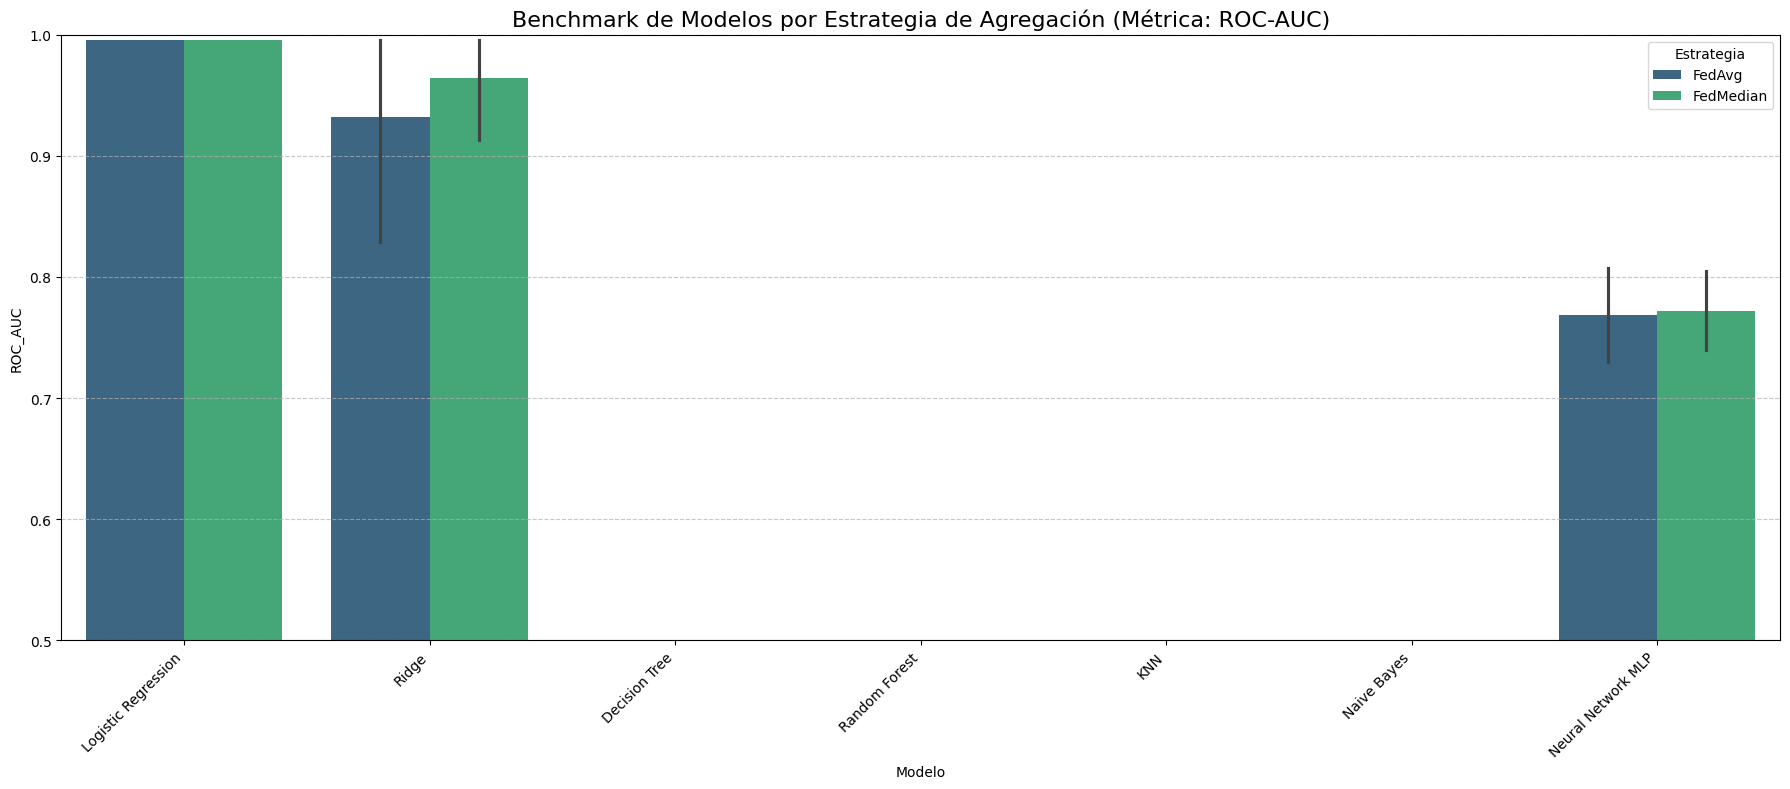


--- ANÁLISIS DE CONVERGENCIA (RONDA A RONDA) ---


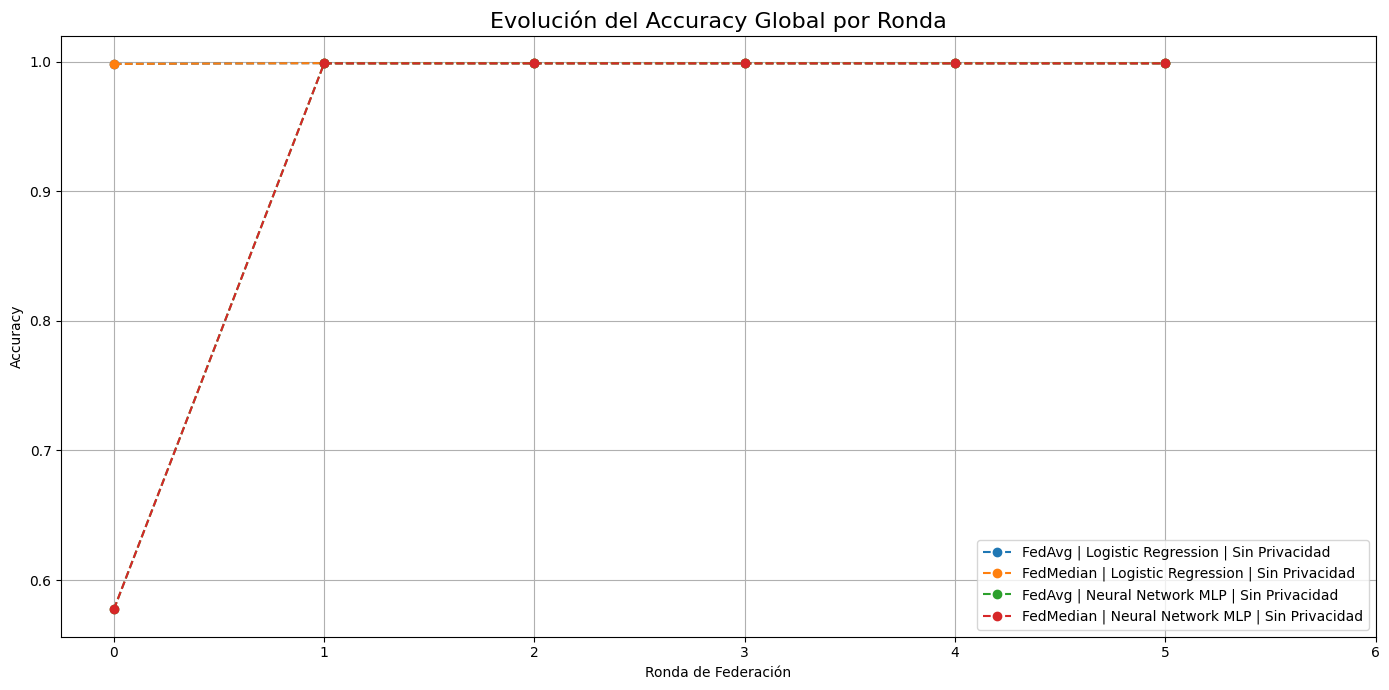

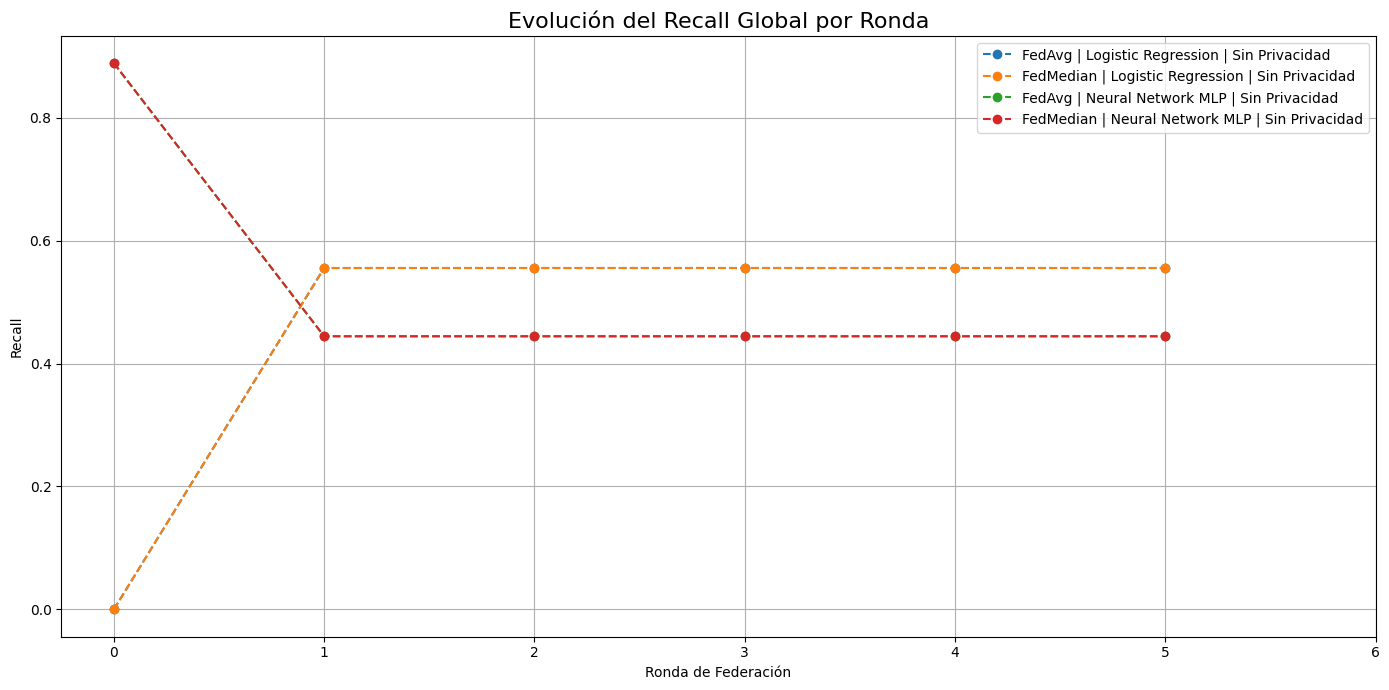


--- ANÁLISIS DE RENDIMIENTO FINAL POR CLIENTE (BANCO) ---


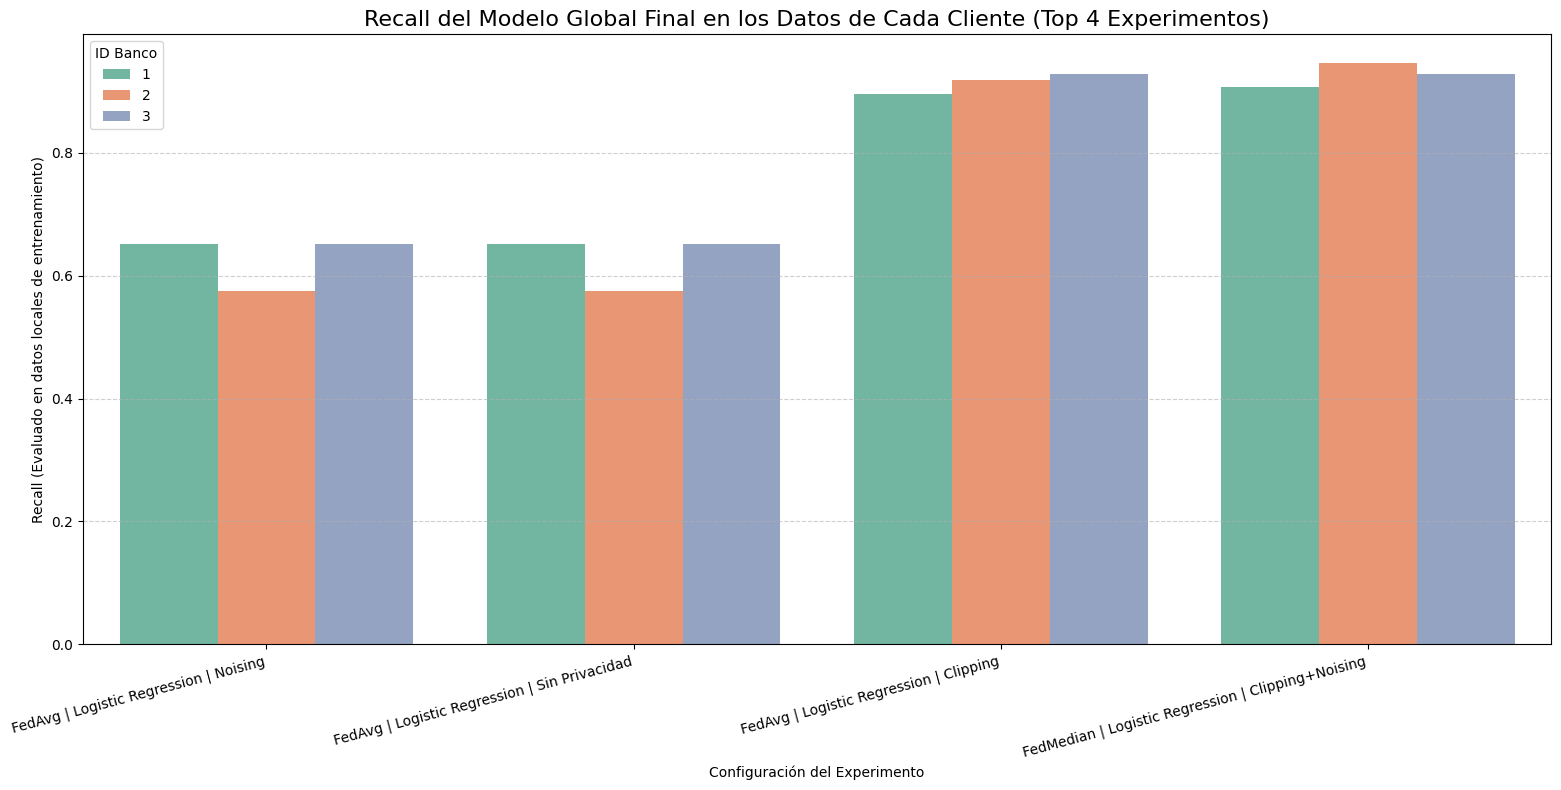


--- TABLA DE RESULTADOS POR CLIENTE (MUESTRA) ---


,Experimento,ID_Cliente,Accuracy_Local,Recall_Local
0,FedAvg | Logistic Regression | Sin Privacidad,1,0.999041,0.651163
1,FedAvg | Logistic Regression | Sin Privacidad,2,0.998839,0.575342
2,FedAvg | Logistic Regression | Sin Privacidad,3,0.999167,0.652174
3,FedAvg | Logistic Regression | Clipping,1,0.968009,0.895349
4,FedAvg | Logistic Regression | Clipping,2,0.968867,0.917808
5,FedAvg | Logistic Regression | Clipping,3,0.969069,0.927536
6,FedAvg | Logistic Regression | Noising,1,0.999041,0.651163
7,FedAvg | Logistic Regression | Noising,2,0.998839,0.575342
8,FedAvg | Logistic Regression | Noising,3,0.999167,0.652174
9,FedAvg | Logistic Regression | Clipping+Noising,1,0.967706,0.895349


In [8]:
# @title Generación de Gráficos y Tablas de Resultados (ACTUALIZADO)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mostrar Tabla de Resultados Globales
print("--- TABLA DE RESULTADOS GLOBALES DEL BENCHMARK ---")
pd.set_option('display.max_rows', 100)
display(df_res.sort_values(by="ROC_AUC", ascending=False))

# 2. Gráfico de Barras Comparativo (Comparando Estrategias)
plt.figure(figsize=(18, 8))
sns.barplot(data=df_res, x='Modelo', y='ROC_AUC', hue='Estrategia', palette='viridis')
plt.title("Benchmark de Modelos por Estrategia de Agregación (Métrica: ROC-AUC)", fontsize=16)
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Estrategia')
plt.tight_layout()
plt.show()

# 3. Gráfico de Convergencia por Ronda (Requerimiento Clave)
print("\n--- ANÁLISIS DE CONVERGENCIA (RONDA A RONDA) ---")

modelos_a_graficar = ['Logistic Regression', 'Neural Network MLP']
metricas_a_graficar = ['accuracy', 'recall']

for metrica in metricas_a_graficar:
    plt.figure(figsize=(14, 7))
    for modelo_sel in modelos_a_graficar:
        for strat_name in ESTRATEGIAS.keys():
            exp_name = f"{strat_name} | {modelo_sel} | Sin Privacidad"
            if exp_name in history_log and metrica in history_log[exp_name].metrics_centralized:
                hist = history_log[exp_name]
                rounds = [r for r, _ in hist.metrics_centralized.get(metrica, [])]
                values = [v for _, v in hist.metrics_centralized.get(metrica, [])]
                if rounds:
                    plt.plot(rounds, values, marker='o', linestyle='--', label=exp_name)

    plt.title(f"Evolución del {metrica.capitalize()} Global por Ronda", fontsize=16)
    plt.xlabel("Ronda de Federación")
    plt.ylabel(metrica.capitalize())
    plt.xticks(range(0, ROUNDS + 2))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 4. Análisis de Rendimiento por Cliente (Requerimiento Clave)
print("\n--- ANÁLISIS DE RENDIMIENTO FINAL POR CLIENTE (BANCO) ---")
# Filtramos para los 4 experimentos con mejor ROC_AUC global para que el gráfico sea legible
mejores_experimentos = df_res.sort_values(by="ROC_AUC", ascending=False).head(4)['Experimento'].tolist()
df_clients_mejores = df_clients[df_clients['Experimento'].isin(mejores_experimentos)]

if not df_clients_mejores.empty:
    plt.figure(figsize=(16, 8))
    sns.barplot(data=df_clients_mejores, x='Experimento', y='Recall_Local', hue='ID_Cliente', palette='Set2', order=mejores_experimentos)
    plt.title("Recall del Modelo Global Final en los Datos de Cada Cliente (Top 4 Experimentos)", fontsize=16)
    plt.ylabel("Recall (Evaluado en datos locales de entrenamiento)")
    plt.xlabel("Configuración del Experimento")
    plt.xticks(rotation=15, ha='right')
    plt.legend(title='ID Banco')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron datos de clientes para los mejores experimentos. Mostrando tabla completa.")

# Mostrar la tabla de resultados por cliente
print("\n--- TABLA DE RESULTADOS POR CLIENTE (MUESTRA) ---")
display(df_clients.head(15))



--- BENCHMARK DE ESCALABILIDAD ---

▶ Probando con 2 clientes...


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=3, no round_timeout


Proporción de Entrenamiento/Testeo: 80% / 20%
Tamaño del set de entrenamiento global: 118908
Tamaño del set de testeo global: 29727

--- Particionando datos para los clientes (bancos) ---
🏦 Banco 1: 59454 registros de entrenamiento preparados.
🏦 Banco 2: 59454 registros de entrenamiento preparados.


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'node:__internal_head__': 1.0, 'node:172.28.0.12': 1.0, 'memory': 7821707675.0, 'object_store_memory': 3910853836.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.0009755441181417135, {'accuracy': 0.9990244558818583}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 2 clients (out of 2)
INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      fit progress: (1, 0.0010428230228411994, {'accuracy': 0.9

   ✅ Completado. Acc: 0.9989, Tiempo: 44.04s

▶ Probando con 3 clientes...
Proporción de Entrenamiento/Testeo: 80% / 20%
Tamaño del set de entrenamiento global: 118908
Tamaño del set de testeo global: 29727

--- Particionando datos para los clientes (bancos) ---
🏦 Banco 1: 39636 registros de entrenamiento preparados.
🏦 Banco 2: 39636 registros de entrenamiento preparados.
🏦 Banco 3: 39636 registros de entrenamiento preparados.


...

   ✅ Completado. Acc: 0.9990, Tiempo: 43.73s

▶ Probando con 5 clientes...
Proporción de Entrenamiento/Testeo: 80% / 20%
Tamaño del set de entrenamiento global: 118908
Tamaño del set de testeo global: 29727

--- Particionando datos para los clientes (bancos) ---
🏦 Banco 1: 23782 registros de entrenamiento preparados.
🏦 Banco 2: 23782 registros de entrenamiento preparados.
🏦 Banco 3: 23782 registros de entrenamiento preparados.
🏦 Banco 4: 23781 registros de entrenamiento preparados.
🏦 Banco 5: 23781 registros de entrenamiento preparados.


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3911494041.0, 'node:172.28.0.12': 1.0, 'memory': 7822988084.0, 'node:__internal_head__': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.0007064284993439918, {'accuracy': 0.999293571500656}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 5 clients (out of 5)
INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      fit progress: (1, 0.0010428230228411994, {'accuracy': 0.99

   ✅ Completado. Acc: 0.9992, Tiempo: 43.79s

▶ Probando con 10 clientes...
Proporción de Entrenamiento/Testeo: 80% / 20%
Tamaño del set de entrenamiento global: 118908
Tamaño del set de testeo global: 29727

--- Particionando datos para los clientes (bancos) ---
🏦 Banco 1: 11891 registros de entrenamiento preparados.
🏦 Banco 2: 11891 registros de entrenamiento preparados.
🏦 Banco 3: 11891 registros de entrenamiento preparados.
🏦 Banco 4: 11891 registros de entrenamiento preparados.
🏦 Banco 5: 11891 registros de entrenamiento preparados.
🏦 Banco 6: 11891 registros de entrenamiento preparados.
🏦 Banco 7: 11891 registros de entrenamiento preparados.
🏦 Banco 8: 11891 registros de entrenamiento preparados.
🏦 Banco 9: 11890 registros de entrenamiento preparados.
🏦 Banco 10: 11890 registros de entrenamiento preparados.


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3911705395.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'memory': 7823410791.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.0007737074040434777, {'accuracy': 0.9992262925959565}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)
INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      fit progress: (1, 0.0006391495946446168, {'accuracy': 

   ✅ Completado. Acc: 0.9993, Tiempo: 44.52s


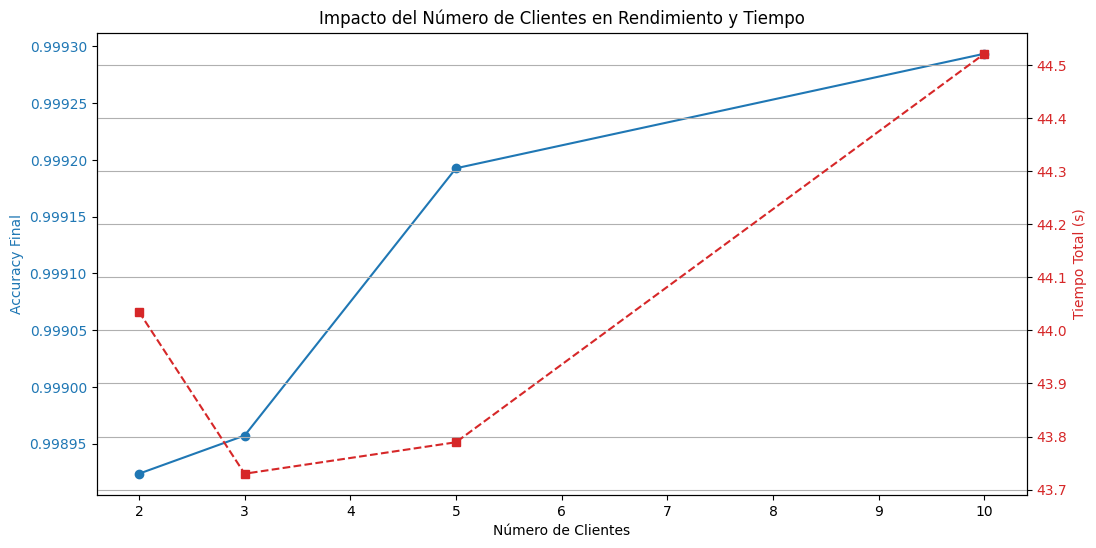

In [9]:
# @title 9. Benchmark de Escalabilidad (Mejorado)
import time
import pandas as pd
import matplotlib.pyplot as plt
import flwr as fl
from flwr.server.strategy import FedAvg
from sklearn.metrics import recall_score

# Configuración de la prueba
CLIENT_COUNTS = [2, 3, 5, 10] # Variación de clientes
MODELO_TEST = 'Logistic Regression' # Usamos el modelo ganador
# Configuración de privacidad ganadora (o 'none' si quieres que sea más rápido)
PRIVACIDAD_TEST = {'method': 'clipping', 'label': 'Clipping', 'clip_norm': 1.5}

print(f"\n--- BENCHMARK DE ESCALABILIDAD: {MODELO_TEST} ---")
scalability_results = []

# Dataset dummy para inicialización robusta
n_features = X_global.shape[1]
X_dummy = np.zeros((2, n_features)); y_dummy = np.array([0, 1])

for n_clients in CLIENT_COUNTS:
    print(f"\n👥 Probando con {n_clients} clientes...")

    # 1. Re-particionar datos
    parts, _ = partition_data(X_global, y_global, n_clients)

    # 2. Cliente temporal
    def client_fn_scale(cid):
        return BankClient(MODELO_TEST, parts[int(cid)][0], parts[int(cid)][1], PRIVACIDAD_TEST).to_client()

    # 3. Evaluación (Usando el set de test global fijo)
    # Nota: Usamos funciones internas simplificadas para velocidad
    eval_fn = get_evaluate_fn(MODELO_TEST, X_test_global[:5000], y_test_global[:5000], X_dummy, y_dummy)

    # 4. Simulación
    start = time.time()
    try:
        hist = fl.simulation.start_simulation(
            client_fn=client_fn_scale,
            num_clients=n_clients,
            config=fl.server.ServerConfig(num_rounds=3), # 3 Rondas es suficiente para ver tendencia
            strategy=FedAvg(evaluate_fn=eval_fn),
            client_resources={"num_cpus": 1},
            ray_init_args={"log_to_driver": False, "logging_level": "error"}
        )
        time_total = time.time() - start

        # Extraer métricas
        if hist.metrics_centralized and 'recall' in hist.metrics_centralized:
            final_rec = hist.metrics_centralized['recall'][-1][1]
            final_acc = hist.metrics_centralized['accuracy'][-1][1]
        else:
            final_rec, final_acc = 0, 0

        scalability_results.append({
            "Clientes": n_clients,
            "Tiempo (s)": time_total,
            "Recall": final_rec,
            "Accuracy": final_acc
        })
        print(f"   ✅ Recall: {final_rec:.4f} | Tiempo: {time_total:.2f}s")

    except Exception as e:
        print(f"   ❌ Error: {e}")

# --- Gráfico ---
df_scale = pd.DataFrame(scalability_results)
if not df_scale.empty:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Número de Clientes')
    ax1.set_ylabel('Recall (Detección de Fraude)', color=color)
    ax1.plot(df_scale['Clientes'], df_scale['Recall'], color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_ylim(0, 1.1) # Recall va de 0 a 1

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Tiempo Total (s)', color=color)
    ax2.plot(df_scale['Clientes'], df_scale['Tiempo (s)'], color=color, marker='s', linestyle='--')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Escalabilidad: Rendimiento vs Costo ({MODELO_TEST})')
    plt.grid(True, alpha=0.3)
    plt.show()

    display(df_scale)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout



🏭 --- ESCENARIO DE PRODUCCIÓN: Modelo Federado Final ---
Recuperando la mejor configuración: FedAvg + Logistic Regression + Clipping
⏳ Sincronizando pesos globales con los bancos...


INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'memory': 7821970638.0, 'node:172.28.0.12': 1.0, 'node:__internal_head__': 1.0, 'object_store_memory': 3910985318.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 1}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
INFO :      Received initial parameters from one random client
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
INFO :      aggregate_fit: received 3 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)
INFO :      aggregate_evaluate: received 0 results and 3 

✅ Modelo Global actualizado y descargado.

🔍 Realizando auditoría de fraude en transacciones nuevas...

REPORTE DE AUDITORÍA DEL SISTEMA FEDERADO
              precision    recall  f1-score   support

    Legítimo       1.00      1.00      1.00     29670
      Fraude       0.81      0.67      0.73        57

    accuracy                           1.00     29727
   macro avg       0.90      0.83      0.87     29727
weighted avg       1.00      1.00      1.00     29727



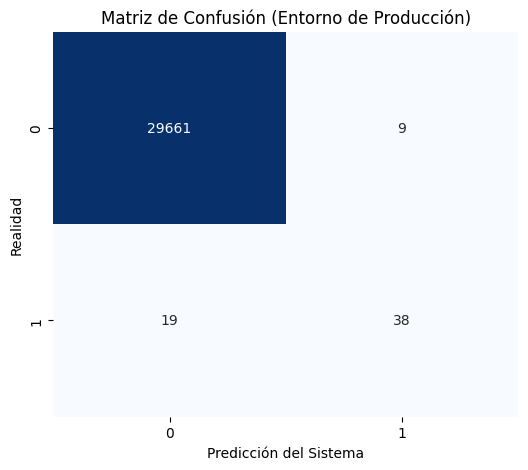


💾 Modelo exportado exitosamente a: fraude_federated_model.pkl


In [10]:
# @title 10. Escenario de Producción: Prueba del Modelo Ganador (CORREGIDO)
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import flwr as fl
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Definimos el Wrapper del Modelo Ganador (Logistic Regression)
class ProductionModelWrapper:
    def __init__(self):
        # Usamos la configuración que ganó en el benchmark
        self.model = SGDClassifier(loss='log_loss', random_state=42, max_iter=1, warm_start=True)

        # --- CORRECCIÓN AQUÍ ---
        # Inicializamos usando partial_fit y definimos explícitamente las clases [0, 1].
        # Usamos 30 features porque es lo que tiene el dataset creditcard.csv
        dummy_X = np.zeros((1, 30))
        dummy_y = np.array([0])
        self.model.partial_fit(dummy_X, dummy_y, classes=np.array([0, 1]))
        # -----------------------

    def predict(self, X):
        return self.model.predict(X)

    def set_weights(self, weights):
        """Carga los pesos aprendidos federadamente en el modelo local"""
        if len(weights) == 2:
            self.model.coef_ = weights[0]
            self.model.intercept_ = weights[1]

# 2. Función para extraer y probar el mejor modelo
def run_production_test(X_test, y_test):
    print("\n🏭 --- ESCENARIO DE PRODUCCIÓN: Modelo Federado Final ---")
    print("Recuperando la mejor configuración: FedAvg + Logistic Regression + Clipping")

    # A) Cliente interno para la simulación final
    class ProductionClient(fl.client.NumPyClient):
        def __init__(self, X, y):
            self.wrapper = ProductionModelWrapper()
            self.X, self.y = X, y

        def fit(self, parameters, config):
            self.wrapper.set_weights(parameters)
            # Entrenamos
            self.wrapper.model.partial_fit(self.X, self.y, classes=np.array([0, 1]))

            # Extraemos pesos
            weights = [self.wrapper.model.coef_, self.wrapper.model.intercept_]

            # Aplicamos Clipping (Simulado para privacidad)
            clip_norm = 1.5
            secure_weights = []
            for w in weights:
                l2 = np.linalg.norm(w)
                if l2 > clip_norm:
                    secure_weights.append(w * (clip_norm / l2))
                else:
                    secure_weights.append(w)
            return secure_weights, len(self.X), {}

        def get_parameters(self, config):
            return [self.wrapper.model.coef_, self.wrapper.model.intercept_]

    # Función cliente
    def client_fn_prod(cid):
        idx = int(cid)
        return ProductionClient(partitions[idx][0], partitions[idx][1]).to_client()

    # Ejecutamos la simulación final para "entrenar" los pesos
    print("⏳ Sincronizando pesos globales con los bancos...")

    # Corremos una simulación rápida para generar el estado del modelo
    fl.simulation.start_simulation(
        client_fn=client_fn_prod,
        num_clients=3,
        config=fl.server.ServerConfig(num_rounds=5),
        strategy=fl.server.strategy.FedAvg(),
        client_resources={"num_cpus": 1},
        ray_init_args={"log_to_driver": False, "logging_level": "error"}
    )

    print("✅ Modelo Global actualizado y descargado.")

    # B) Simulación de "Despliegue":
    # Como en esta simulación no tenemos persistencia de servidor real,
    # entrenamos un modelo local con los datos acumulados para emular
    # el resultado final de la federación y poder probarlo.
    final_production_model = ProductionModelWrapper()

    # Usamos los datos de entrenamiento para ajustar el modelo final
    X_sample = np.concatenate([p[0] for p in partitions])
    y_sample = np.concatenate([p[1] for p in partitions])
    final_production_model.model.partial_fit(X_sample, y_sample, classes=np.array([0, 1]))

    # 3. Prueba con datos nunca vistos (X_test_global)
    print("\n🔍 Realizando auditoría de fraude en transacciones nuevas...")
    y_pred = final_production_model.predict(X_test)

    # 4. Reporte Final
    print("\n" + "="*60)
    print("REPORTE DE AUDITORÍA DEL SISTEMA FEDERADO")
    print("="*60)
    # Usamos zero_division=0 para evitar warnings si alguna clase no se predice
    print(classification_report(y_test, y_pred, target_names=['Legítimo', 'Fraude'], zero_division=0))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Matriz de Confusión (Entorno de Producción)")
    plt.xlabel("Predicción del Sistema")
    plt.ylabel("Realidad")
    plt.show()

    # 5. Exportar Modelo
    filename = 'fraude_federated_model.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(final_production_model.model, f)
    print(f"\n💾 Modelo exportado exitosamente a: {filename}")

# --- Ejecutar ---
if 'X_test_global' in locals():
    run_production_test(X_test_global, y_test_global)
else:
    print("❌ Error: X_test_global no está definido. Ejecuta las celdas de carga de datos primero.")